# Kidney Disease Support Model — NHANES + Ontology Matching

هذه النوتبوك تبني **Kidney Model** مطابق للفورم عندك:

- Creatinine (mg/dL)
- BUN (mg/dL)
- eGFR (mL/min/1.73m²)
- Uric Acid (mg/dL)

وتعمل:
1. قراءة ملفات NHANES.
2. دمج الملفات باستخدام `SEQN`.
3. حساب eGFR طبيًا من Creatinine + Age + Gender.
4. بناء target للـ kidney risk.
5. تدريب 4 موديلات.
6. مقارنة الموديلات واختيار الأفضل.
7. استخراج ontology findings.
8. حفظ أفضل model artifacts للاستخدام في FastAPI.

## ملاحظة مهمة عن الـ Target

الداتا لا تحتوي دائمًا على diagnosis label جاهز باسم CKD، لذلك سنبني target طبي باستخدام:

- `eGFR`
- `Urine Albumin-Creatinine Ratio (ACR)`

التصنيف المستخدم:

| Condition | Target |
|---|---|
| eGFR < 60 | Reduced_Kidney_Function |
| ACR >= 30 مع eGFR >= 60 | Kidney_Damage_Risk |
| غير ذلك | Normal |

> الـ ACR مستخدم لبناء الـ label فقط، وليس feature في الفورم، لأن الفورم الحالي لا يحتوي عليه.

In [1]:
# =========================
# 1) Imports
# =========================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
# =========================
# 2) Load NHANES XPT files
# =========================

BIOPRO_PATH = "BIOPRO_L.xpt"
DEMO_PATH = "DEMO_L (1).xpt"
ALB_CR_PATH = "ALB_CR_L.xpt"

bio = pd.read_sas(BIOPRO_PATH)
demo = pd.read_sas(DEMO_PATH)
alb_cr = pd.read_sas(ALB_CR_PATH)

print("BIOPRO shape:", bio.shape)
print("DEMO shape:", demo.shape)
print("ALB_CR shape:", alb_cr.shape)

BIOPRO shape: (7199, 42)
DEMO shape: (11933, 27)
ALB_CR shape: (8493, 8)


In [3]:
# =========================
# 3) Select needed columns
# =========================
# NHANES columns:
# LBXSCR  = Serum Creatinine (mg/dL)
# LBXSBU  = Blood Urea Nitrogen / BUN (mg/dL)
# LBXSUA  = Uric Acid (mg/dL)
# RIDAGEYR = Age in years
# RIAGENDR = Gender (1 = Male, 2 = Female)
# URDACT = Urine albumin/creatinine ratio (mg/g)

bio_selected = bio[["SEQN", "LBXSCR", "LBXSBU", "LBXSUA"]].copy()
demo_selected = demo[["SEQN", "RIDAGEYR", "RIAGENDR"]].copy()
alb_selected = alb_cr[["SEQN", "URDACT"]].copy()

df = bio_selected.merge(demo_selected, on="SEQN", how="inner")
df = df.merge(alb_selected, on="SEQN", how="left")

df.head()

,SEQN,LBXSCR,LBXSBU,LBXSUA,RIDAGEYR,RIAGENDR,URDACT
0,130378.0,0.80,11.0,5.1,43.0,1.0,17.00
1,130379.0,0.79,24.0,8.5,66.0,1.0,6.64
2,130380.0,0.64,10.0,4.4,44.0,2.0,7.92
3,130386.0,0.82,17.0,6.0,34.0,1.0,4.07
4,130387.0,0.76,15.0,6.2,68.0,2.0,25.78


In [4]:
# =========================
# 4) Rename columns to readable names
# =========================

df = df.rename(columns={
    "LBXSCR": "creatinine",
    "LBXSBU": "bun",
    "LBXSUA": "uric_acid",
    "RIDAGEYR": "age",
    "RIAGENDR": "gender",
    "URDACT": "acr"
})

df.head()

,SEQN,creatinine,bun,uric_acid,age,gender,acr
0,130378.0,0.80,11.0,5.1,43.0,1.0,17.00
1,130379.0,0.79,24.0,8.5,66.0,1.0,6.64
2,130380.0,0.64,10.0,4.4,44.0,2.0,7.92
3,130386.0,0.82,17.0,6.0,34.0,1.0,4.07
4,130387.0,0.76,15.0,6.2,68.0,2.0,25.78


In [5]:
# =========================
# 5) Calculate eGFR using CKD-EPI 2021 race-free equation
# =========================
# Formula:
# eGFR = 142 × min(Scr/k,1)^alpha × max(Scr/k,1)^-1.200 × 0.9938^Age × 1.012 if female
#
# k = 0.7 for female, 0.9 for male
# alpha = -0.241 for female, -0.302 for male

def calculate_egfr_2021(creatinine, age, gender):
    female = gender == 2
    k = 0.7 if female else 0.9
    alpha = -0.241 if female else -0.302

    egfr = (
        142
        * (min(creatinine / k, 1) ** alpha)
        * (max(creatinine / k, 1) ** -1.200)
        * (0.9938 ** age)
        * (1.012 if female else 1)
    )
    return egfr

df["egfr"] = df.apply(
    lambda row: calculate_egfr_2021(row["creatinine"], row["age"], row["gender"]),
    axis=1
)

df[["creatinine", "bun", "egfr", "uric_acid", "acr", "age", "gender"]].head()

,creatinine,bun,egfr,uric_acid,acr,age,gender
0,0.80,11.0,112.614180,5.1,17.00,43.0,1.0
1,0.79,24.0,97.975999,8.5,6.64,66.0,1.0
2,0.64,10.0,111.687296,4.4,7.92,44.0,2.0
3,0.82,17.0,118.212538,6.0,4.07,34.0,1.0
4,0.76,15.0,85.298556,6.2,25.78,68.0,2.0


In [6]:
# =========================
# 6) Cleaning
# =========================

# Remove rows with missing important values
df = df.dropna(subset=["creatinine", "bun", "egfr", "uric_acid", "age", "gender", "acr"])

# Remove impossible values
df = df[
    (df["creatinine"] > 0) &
    (df["bun"] > 0) &
    (df["uric_acid"] > 0) &
    (df["egfr"] > 0) &
    (df["age"] >= 18)
].copy()

print(df.shape)
df[["creatinine", "bun", "egfr", "uric_acid", "acr", "age"]].describe()

(5550, 8)


,creatinine,bun,egfr,uric_acid,acr,age
count,5550.000000,5550.000000,5550.000000,5550.000000,5550.000000,5550.000000
mean,0.887901,15.003063,92.434125,5.154018,34.941910,52.540541
std,0.361219,5.738504,21.648068,1.411875,292.099962,17.979837
min,0.350000,4.000000,3.508700,1.100000,0.220000,18.000000
25%,0.720000,11.000000,78.589344,4.100000,5.130000,37.000000
50%,0.840000,14.000000,94.315383,5.100000,7.850000,56.000000
75%,1.000000,17.000000,107.470049,6.000000,14.350000,67.000000
max,15.170000,74.000000,148.977312,13.200000,14708.280000,80.000000


In [7]:
# =========================
# 7) Build medical target
# =========================

def kidney_target(row):
    if row["egfr"] < 60:
        return "Reduced_Kidney_Function"
    elif row["acr"] >= 30:
        return "Kidney_Damage_Risk"
    else:
        return "Normal"

df["target"] = df.apply(kidney_target, axis=1)

df["target"].value_counts()

target
Normal                     4601
Kidney_Damage_Risk          495
Reduced_Kidney_Function     454
Name: count, dtype: int64

In [8]:
# =========================
# 8) Ontology-style findings
# =========================

def kidney_findings(row):
    findings = []

    if row["creatinine"] > 1.3:
        findings.append("High_Creatinine")
    if row["bun"] > 20:
        findings.append("High_BUN")
    if row["egfr"] < 60:
        findings.append("Low_eGFR")
    if row["uric_acid"] > 7:
        findings.append("High_Uric_Acid")
    if row["acr"] >= 30:
        findings.append("Albuminuria")

    if not findings:
        findings.append("No_Major_Kidney_Finding")

    return findings

df["ontology_findings"] = df.apply(kidney_findings, axis=1)

df[["creatinine", "bun", "egfr", "uric_acid", "acr", "target", "ontology_findings"]].head(10)

,creatinine,bun,egfr,uric_acid,acr,target,ontology_findings
0,0.80,11.0,112.614180,5.1,17.00,Normal,[No_Major_Kidney_Finding]
1,0.79,24.0,97.975999,8.5,6.64,Normal,"[High_BUN, High_Uric_Acid]"
2,0.64,10.0,111.687296,4.4,7.92,Normal,[No_Major_Kidney_Finding]
3,0.82,17.0,118.212538,6.0,4.07,Normal,[No_Major_Kidney_Finding]
4,0.76,15.0,85.298556,6.2,25.78,Normal,[No_Major_Kidney_Finding]
7,0.80,11.0,100.959522,6.9,11.05,Normal,[No_Major_Kidney_Finding]
8,0.55,11.0,124.044304,4.8,19.42,Normal,[No_Major_Kidney_Finding]
9,0.59,17.0,94.512138,3.9,10.08,Normal,[No_Major_Kidney_Finding]
10,0.99,15.0,99.375157,6.4,5.07,Normal,[No_Major_Kidney_Finding]
11,0.84,12.0,105.581019,5.0,6.29,Normal,[No_Major_Kidney_Finding]


In [9]:
# =========================
# 9) Prepare ML data
# =========================
# These features match your frontend form.

feature_columns = ["creatinine", "bun", "egfr", "uric_acid"]

X = df[feature_columns]
y = df["target"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", list(label_encoder.classes_))
print("Feature columns:", feature_columns)

Classes: ['Kidney_Damage_Risk', 'Normal', 'Reduced_Kidney_Function']
Feature columns: ['creatinine', 'bun', 'egfr', 'uric_acid']


In [10]:
# =========================
# 10) Train/Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4440, 4)
Test shape: (1110, 4)


In [11]:
# =========================
# 11) Train 4 Models
# =========================

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=6
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        max_depth=10
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

results = []

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-score
3,Gradient Boosting,0.906306,0.843369,0.906306,0.867877
2,Random Forest,0.870270,0.845524,0.870270,0.857101
1,Decision Tree,0.831532,0.853069,0.831532,0.841742
0,Logistic Regression,0.611712,0.846790,0.611712,0.684654


In [12]:
# =========================
# 12) Select Best Model
# =========================

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)
results_df

Best Model: Gradient Boosting


,Model,Accuracy,Precision,Recall,F1-score
3,Gradient Boosting,0.906306,0.843369,0.906306,0.867877
2,Random Forest,0.870270,0.845524,0.870270,0.857101
1,Decision Tree,0.831532,0.853069,0.831532,0.841742
0,Logistic Regression,0.611712,0.846790,0.611712,0.684654


In [13]:
# =========================
# 13) Detailed Evaluation for Best Model
# =========================

y_pred_best = best_model.predict(X_test)

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=label_encoder.classes_,
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred_best)
print("Confusion Matrix:")
print(cm)

Classification Report:
                         precision    recall  f1-score   support

     Kidney_Damage_Risk       0.14      0.01      0.02        99
                 Normal       0.90      0.99      0.95       920
Reduced_Kidney_Function       1.00      0.99      0.99        91

               accuracy                           0.91      1110
              macro avg       0.68      0.66      0.65      1110
           weighted avg       0.84      0.91      0.87      1110

Confusion Matrix:
[[  1  98   0]
 [  5 915   0]
 [  1   0  90]]


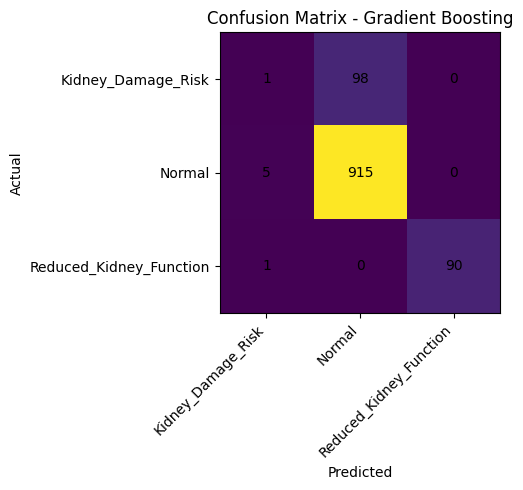

In [14]:
# =========================
# 14) Plot Confusion Matrix
# =========================

plt.figure(figsize=(7, 5))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=45, ha="right")
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

,Feature,Importance
2,egfr,0.928865
0,creatinine,0.033311
3,uric_acid,0.020223
1,bun,0.017601


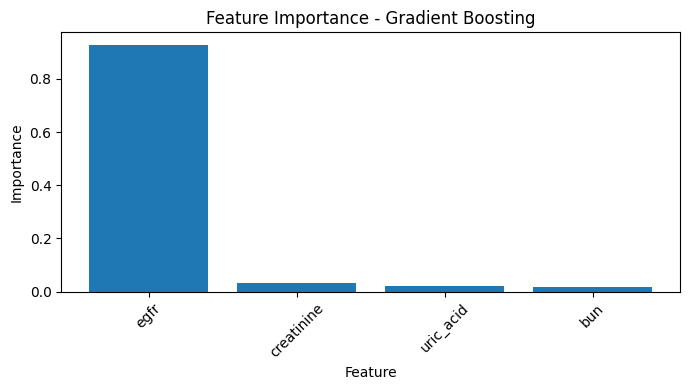

In [15]:
# =========================
# 15) Feature Importance
# =========================

def get_feature_importance(model, feature_columns):
    # If Pipeline, get final estimator
    final_model = model.named_steps["model"] if hasattr(model, "named_steps") else model

    if hasattr(final_model, "feature_importances_"):
        importances = final_model.feature_importances_
    elif hasattr(final_model, "coef_"):
        importances = np.mean(np.abs(final_model.coef_), axis=0)
    else:
        return None

    return pd.DataFrame({
        "Feature": feature_columns,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

importance_df = get_feature_importance(best_model, feature_columns)

if importance_df is not None:
    display(importance_df)

    plt.figure(figsize=(7, 4))
    plt.bar(importance_df["Feature"], importance_df["Importance"])
    plt.title(f"Feature Importance - {best_model_name}")
    plt.xlabel("Feature")
    plt.ylabel("Importance")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance is not available for this model.")

In [16]:
# =========================
# 16) Prediction Function for FastAPI / Streamlit
# =========================

def predict_kidney_status(creatinine, bun, egfr, uric_acid):
    input_df = pd.DataFrame([{
        "creatinine": creatinine,
        "bun": bun,
        "egfr": egfr,
        "uric_acid": uric_acid
    }])

    pred_encoded = best_model.predict(input_df)[0]
    pred_label = label_encoder.inverse_transform([pred_encoded])[0]

    probabilities = None
    if hasattr(best_model, "predict_proba"):
        proba = best_model.predict_proba(input_df)[0]
        probabilities = {
            label_encoder.classes_[i]: round(float(proba[i]), 4)
            for i in range(len(label_encoder.classes_))
        }

    # Ontology findings from user input
    temp_row = {
        "creatinine": creatinine,
        "bun": bun,
        "egfr": egfr,
        "uric_acid": uric_acid,
        "acr": 0
    }

    findings = []
    if creatinine > 1.3:
        findings.append("High_Creatinine")
    if bun > 20:
        findings.append("High_BUN")
    if egfr < 60:
        findings.append("Low_eGFR")
    if uric_acid > 7:
        findings.append("High_Uric_Acid")
    if not findings:
        findings.append("No_Major_Kidney_Finding")

    recommended_tests = []
    if pred_label != "Normal" or "Low_eGFR" in findings:
        recommended_tests = [
            "Urine Albumin-Creatinine Ratio (ACR)",
            "Repeat Serum Creatinine",
            "Urinalysis",
            "Electrolytes",
            "Kidney Ultrasound if clinically indicated"
        ]

    return {
        "prediction": pred_label,
        "probabilities": probabilities,
        "ontology_findings": findings,
        "recommended_tests": recommended_tests,
        "specialist": "Nephrologist" if pred_label != "Normal" else "Primary care follow-up"
    }

# Example
predict_kidney_status(creatinine=1.8, bun=35, egfr=45, uric_acid=8.2)

{'prediction': 'Reduced_Kidney_Function',
 'probabilities': {'Kidney_Damage_Risk': 0.0001,
  'Normal': 0.0001,
  'Reduced_Kidney_Function': 0.9998},
 'ontology_findings': ['High_Creatinine',
  'High_BUN',
  'Low_eGFR',
  'High_Uric_Acid'],
 'recommended_tests': ['Urine Albumin-Creatinine Ratio (ACR)',
  'Repeat Serum Creatinine',
  'Urinalysis',
  'Electrolytes',
  'Kidney Ultrasound if clinically indicated'],
 'specialist': 'Nephrologist'}

In [17]:
# =========================
# 17) Save Artifacts
# =========================

joblib.dump(best_model, "kidney_best_model.joblib")
joblib.dump(label_encoder, "kidney_label_encoder.joblib")
joblib.dump(feature_columns, "kidney_feature_columns.joblib")

df.to_csv("nhanes_kidney_cleaned.csv", index=False)

print("Saved:")
print("- kidney_best_model.joblib")
print("- kidney_label_encoder.joblib")
print("- kidney_feature_columns.joblib")
print("- nhanes_kidney_cleaned.csv")

Saved:
- kidney_best_model.joblib
- kidney_label_encoder.joblib
- kidney_feature_columns.joblib
- nhanes_kidney_cleaned.csv


## جاهز للربط مع الـ Ontology

Mapping مقترح:

| UI Feature | Ontology Test |
|---|---|
| creatinine | Creatinine_Test |
| bun | BUN_Test |
| egfr | eGFR_Test |
| uric_acid | Uric_Acid_Test |

Findings:

| Rule | Finding |
|---|---|
| creatinine > 1.3 | High_Creatinine |
| bun > 20 | High_BUN |
| egfr < 60 | Low_eGFR |
| uric_acid > 7 | High_Uric_Acid |

Disease candidates:

| Finding | Disease Candidate |
|---|---|
| Low_eGFR | Chronic_Kidney_Disease_Candidate |
| High_Creatinine | Kidney_Function_Impairment_Candidate |
| High_BUN | Kidney_Function_Impairment_Candidate |
| High_Uric_Acid | Hyperuricemia_Candidate |